## 1. Imports

In [42]:
import os, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.backends.cudnn.benchmark     = True
torch.backends.cudnn.deterministic = False
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32    = True

## 2. Config

In [43]:
class CFG:
    DATA_DIR = Path('/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset')
    OUTPUT_DIR = Path('/kaggle/working')

    # ----- Data -----
    IMG_SIZE   = 224
    VAL_FRAC   = 0.20

    # ----- Model -----
    MODEL_NAME = 'efficientnet_b0'
    PRETRAINED = True
    NUM_CLASSES = 1

    # ----- Training -----
    EPOCHS       = 10
    LR_MAX       = 3e-4
    WEIGHT_DECAY = 1e-5
    NUM_WORKERS = 4
    BATCH_SIZE  = 64
    PREFETCH    = 2
    MIXED_PREC   = True

    POS_WEIGHT   = None

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f"Device: {DEVICE}  |  GPUs: {N_GPUS}")

CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda  |  GPUs: 2


In [44]:
import os
base = '/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset'
for folder in ['Normal', 'Bleeding', 'Ischemia']:
    path = os.path.join(base, folder)
    files = os.listdir(path)
    print(f"{folder}: {len(files)} files, first few: {files[:3]}")

Normal: 2 files, first few: ['DICOM', 'PNG']
Bleeding: 3 files, first few: ['DICOM', 'OVERLAY', 'PNG']
Ischemia: 3 files, first few: ['DICOM', 'OVERLAY', 'PNG']


## 3. Build DataFrame from Folder Structure

In [45]:
CLASS_MAP = {'Normal': 0, 'Bleeding': 1, 'Ischemia': 1}
records = []
for class_name, label in CLASS_MAP.items():
    class_dir = CFG.DATA_DIR / class_name / 'PNG'
    for img_path in sorted(class_dir.glob('*')):
        if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
            records.append({'path': str(img_path), 'label': label,
                            'class_name': class_name})

df = pd.DataFrame(records)
print(f"Total images : {len(df):,}")
print(df['class_name'].value_counts().to_string())

# Compute positive-class weight for BCEWithLogitsLoss
n_neg = (df['label'] == 0).sum()   # Normal
n_pos = (df['label'] == 1).sum()   # Stroke
CFG.POS_WEIGHT = n_neg / max(n_pos, 1)
print(f"\nPos-weight (Normal/Stroke) = {CFG.POS_WEIGHT:.2f}")

Total images : 6,650
class_name
Normal      4427
Ischemia    1130
Bleeding    1093

Pos-weight (Normal/Stroke) = 1.99


## 4. Stratified Train / Val Split

In [46]:
df_train, df_val = train_test_split(
    df,
    test_size=CFG.VAL_FRAC,
    stratify=df['label'],
    random_state=SEED,
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f"Train: {len(df_train):,}  |  Val: {len(df_val):,}")
print("Train label dist:")
print(df_train['class_name'].value_counts().to_string())
print("Val label dist:")
print(df_val['class_name'].value_counts().to_string())

Train: 5,320  |  Val: 1,330
Train label dist:
class_name
Normal      3542
Ischemia     915
Bleeding     863
Val label dist:
class_name
Normal      885
Bleeding    230
Ischemia    215


## 5. Dataset & Augmentations

In [47]:
train_tfm = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05,
                       rotate_limit=10, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.1,
                               contrast_limit=0.1, p=0.3),
    A.GaussNoise(var_limit=(5, 20), p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_tfm = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


class StrokeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.transform = transform
        self.labels = df['label'].tolist()
        self.images = []
        for path in df['path']:
            img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            self.images.append(img)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(image=img)['image']
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          num_workers=0, pin_memory=False)

## 6. DataLoaders

In [48]:
train_dataset = StrokeDataset(df_train, transform=train_tfm)
val_dataset   = StrokeDataset(df_val,   transform=val_tfm)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f"Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}")

Train batches: 167  |  Val batches: 21


## 7. Model

Single output head (binary) instead of the original 6-class multi-label head.

In [49]:
class StrokeModel(nn.Module):
    """EfficientNet-B0 backbone with a lightweight binary classification head."""
    def __init__(self, model_name=CFG.MODEL_NAME, pretrained=CFG.PRETRAINED):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg',
        )
        n_feat = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(n_feat, 256),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)  # shape: (B,)


model = StrokeModel().to(DEVICE)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 4,335,741


## 8. Loss, Optimizer & Scheduler

In [50]:
pos_weight_tensor = torch.tensor([CFG.POS_WEIGHT], dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.LR_MAX,
    weight_decay=CFG.WEIGHT_DECAY,
    fused=True,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CFG.LR_MAX,
    steps_per_epoch=len(train_loader),
    epochs=CFG.EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25.0,
    final_div_factor=1e4,
)

scaler = GradScaler('cuda', enabled=CFG.MIXED_PREC)
print(f"Loss: BCEWithLogitsLoss (pos_weight={CFG.POS_WEIGHT:.2f})")
print("Optimizer / scheduler ready.")

Loss: BCEWithLogitsLoss (pos_weight=1.99)
Optimizer / scheduler ready.


## 9. Training & Validation Loop

In [51]:
def train_epoch(model, loader, optimizer, criterion, scaler, scheduler):
    model.train()
    total_loss = 0.0

    for images, labels in tqdm(loader, desc='Train', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda', enabled=CFG.MIXED_PREC):
            logits = model(images)          # (B,)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc='Val', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast('cuda', enabled=CFG.MIXED_PREC):
            logits = model(images)
            loss   = criterion(logits, labels)

        total_loss += loss.item()
        all_preds.append(torch.sigmoid(logits).cpu())
        all_labels.append(labels.cpu())
a
    return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

## 10. Run Training

In [56]:
import time

best_val_auc = 0.0
history      = []

for epoch in range(1, CFG.EPOCHS + 1):
    lr_now = scheduler.get_last_lr()[0]
    print(f"\n{'='*65}")
    print(f"Epoch {epoch}/{CFG.EPOCHS}  |  LR: {lr_now:.2e}")
    print(f"{'='*65}")

    t0         = time.time()
    train_loss = train_epoch(model, train_loader, optimizer,
                             criterion, scaler, scheduler)
    val_loss, val_preds, val_labels = validate(model, val_loader, criterion)
    elapsed    = time.time() - t0

    # Binary metrics
    y_true  = val_labels.numpy()
    y_score = val_preds.numpy()
    y_pred  = (y_score >= 0.5).astype(int)

    try:
        auc = roc_auc_score(y_true, y_score)
    except ValueError:
        auc = float('nan')
    f1 = f1_score(y_true, y_pred, zero_division=0)

    eta = elapsed * (CFG.EPOCHS - epoch)
    print(f"Train loss : {train_loss:.4f}")
    print(f"Val   loss : {val_loss:.4f}")
    print(f"Val AUC-ROC: {auc:.4f}")
    print(f"Val F1     : {f1:.4f}")
    print(f"Epoch time : {elapsed/60:.1f} min  |  ETA: {eta/60:.0f} min remaining")

    history.append({'epoch': epoch, 'train_loss': train_loss,
                    'val_loss': val_loss, 'auc': auc,
                    'f1': f1, 'epoch_min': elapsed / 60})

    # Save best model (tracked by AUC-ROC)
    if auc > best_val_auc:
        best_val_auc = auc
        state = (model.module.state_dict()
                 if isinstance(model, nn.DataParallel)
                 else model.state_dict())
        torch.save(state, CFG.OUTPUT_DIR / 'best_model.pth')
        print(f"  ✓ Saved best model (AUC={best_val_auc:.4f})")

    # Rolling checkpoint
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     (model.module.state_dict()
                                 if isinstance(model, nn.DataParallel)
                                 else model.state_dict()),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'best_val_auc':         best_val_auc,
        'history':              history,
    }, CFG.OUTPUT_DIR / 'checkpoint_latest.pth')
    print("  ✓ Checkpoint saved.")

print(f"\nTraining complete. Best val AUC-ROC: {best_val_auc:.4f}")


Epoch 1/10  |  LR: 1.20e-05


Train:   0%|          | 0/167 [00:00<?, ?it/s]

Val:   0%|          | 0/21 [00:00<?, ?it/s]

Train loss : 0.8171
Val   loss : 0.4729
Val AUC-ROC: 0.9225
Val F1     : 0.8160
Epoch time : 1.3 min  |  ETA: 12 min remaining
  ✓ Saved best model (AUC=0.9225)
  ✓ Checkpoint saved.

Epoch 2/10  |  LR: 8.43e-05


Train:   0%|          | 0/167 [00:00<?, ?it/s]

...

Val:   0%|          | 0/21 [00:00<?, ?it/s]

Train loss : 0.0920
Val   loss : 0.1136
Val AUC-ROC: 0.9961
Val F1     : 0.9696
Epoch time : 0.4 min  |  ETA: 0 min remaining
  ✓ Saved best model (AUC=0.9961)
  ✓ Checkpoint saved.

Epoch 10/10  |  LR: 1.47e-05


Train:   0%|          | 0/167 [00:00<?, ?it/s]

Val:   0%|          | 0/21 [00:00<?, ?it/s]

Train loss : 0.0823
Val   loss : 0.1193
Val AUC-ROC: 0.9965
Val F1     : 0.9718
Epoch time : 0.4 min  |  ETA: 0 min remaining
  ✓ Saved best model (AUC=0.9965)
  ✓ Checkpoint saved.

Training complete. Best val AUC-ROC: 0.9965


## 11. Final Evaluation on Best Checkpoint

In [57]:
# Reload best weights
state = torch.load(CFG.OUTPUT_DIR / 'best_model.pth', map_location=DEVICE)
state = {k.replace('_orig_mod.', ''): v for k, v in state.items()}
base  = model.module if isinstance(model, nn.DataParallel) else model
base.load_state_dict(state, strict=True)

_, val_preds, val_labels = validate(model, val_loader, criterion)

y_true  = val_labels.numpy()
y_score = val_preds.numpy()
y_pred  = (y_score >= 0.5).astype(int)

auc = roc_auc_score(y_true, y_score)
print(f"Final AUC-ROC : {auc:.4f}")
print()
print(classification_report(
    y_true, y_pred,
    target_names=['Normal', 'Stroke'],
    digits=4,
))

Val:   0%|          | 0/21 [00:00<?, ?it/s]

Final AUC-ROC : 0.9965

              precision    recall  f1-score   support

      Normal     0.9831    0.9887    0.9859       885
      Stroke     0.9773    0.9663    0.9718       445

    accuracy                         0.9812      1330
   macro avg     0.9802    0.9775    0.9788      1330
weighted avg     0.9812    0.9812    0.9812      1330



In [60]:
# Do your filenames encode patient IDs?
print(df['path'].head(10).tolist())

['/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG/10000.png', '/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG/10001.png', '/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG/10004.png', '/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG/10005.png', '/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG/10006.png', '/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG/10008.png', '/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG/10009.png', '/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG/10010.png', '/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset/Normal/PNG/10011.png', '/kaggle/input/datasets/ozguraslank/

## 12. Training History Plots

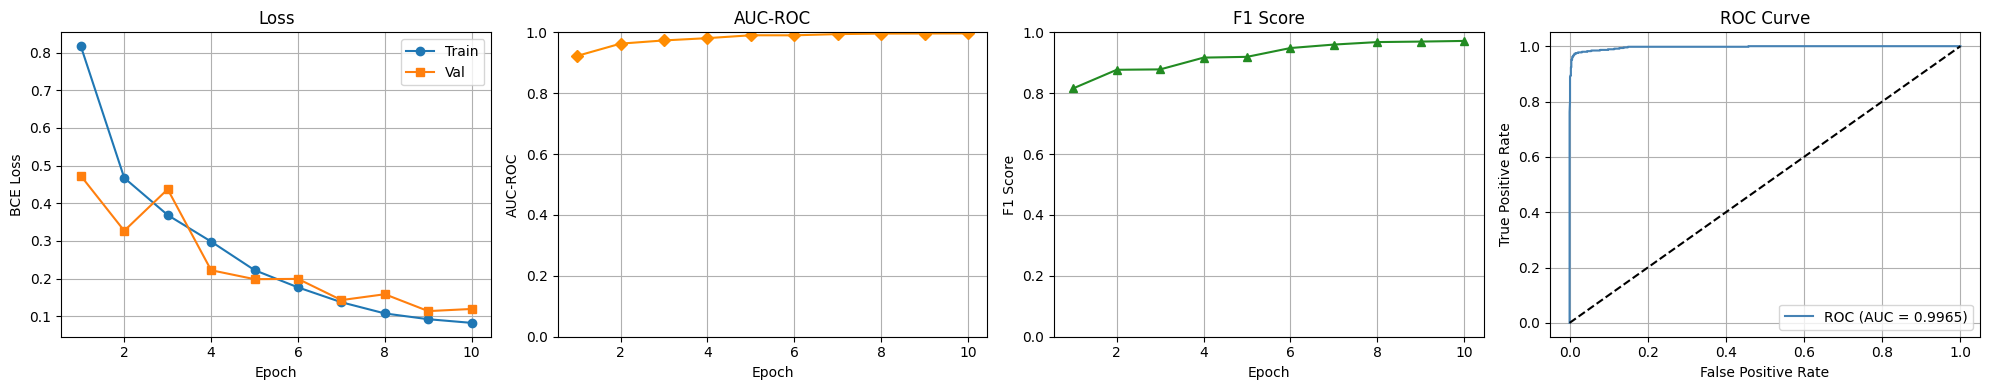

Total training time: 4.7 min


In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as auc_score

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Loss
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train', marker='o')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val',   marker='s')
axes[0].set(xlabel='Epoch', ylabel='BCE Loss', title='Loss')
axes[0].legend(); axes[0].grid(True)

# AUC
axes[1].plot(hist_df['epoch'], hist_df['auc'], color='darkorange', marker='D')
axes[1].set(xlabel='Epoch', ylabel='AUC-ROC', title='AUC-ROC')
axes[1].set_ylim(0, 1); axes[1].grid(True)

# F1
axes[2].plot(hist_df['epoch'], hist_df['f1'], color='forestgreen', marker='^')
axes[2].set(xlabel='Epoch', ylabel='F1 Score', title='F1 Score')
axes[2].set_ylim(0, 1); axes[2].grid(True)

# ROC Curve (final model)
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc     = auc_score(fpr, tpr)
axes[3].plot(fpr, tpr, color='steelblue',
             label=f'ROC (AUC = {roc_auc:.4f})')
axes[3].plot([0, 1], [0, 1], 'k--')
axes[3].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve')
axes[3].legend(); axes[3].grid(True)

plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'training_history.png', dpi=150)
plt.show()
print(f"Total training time: {hist_df['epoch_min'].sum():.1f} min")

## 13. Save Final Outputs

In [59]:
for p in [
    CFG.OUTPUT_DIR / 'best_model.pth',
    CFG.OUTPUT_DIR / 'checkpoint_latest.pth',
    CFG.OUTPUT_DIR / 'training_history.png',
]:
    if p.exists():
        print(f"✓ {p.name}  ({p.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"✗ MISSING: {p.name}")

print("\nDone. Download best_model.pth from the Output tab.")

✓ best_model.pth  (17.6 MB)
✓ checkpoint_latest.pth  (52.5 MB)
✓ training_history.png  (0.1 MB)

Done. Download best_model.pth from the Output tab.


In [62]:
import json, os

# Check what's actually in the output directory
print(os.listdir('/kaggle/working'))

# Save the config
config = {
    "model_name": "efficientnet_b0",
    "img_size": 224,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "threshold": 0.5,
    "classes": {"0": "Normal", "1": "Stroke"},
}

path = '/kaggle/working/inference_config.json'
with open(path, 'w') as f:
    json.dump(config, f, indent=2)

# Verify it actually wrote
print(f"Exists: {os.path.exists(path)}")
print(f"Size: {os.path.getsize(path)} bytes")
print(open(path).read())

['.virtual_documents', 'best_model.pth', 'checkpoint_latest.pth', 'inference_config.json', 'training_history.png']
Exists: True
Size: 230 bytes
{
  "model_name": "efficientnet_b0",
  "img_size": 224,
  "mean": [
    0.485,
    0.456,
    0.406
  ],
  "std": [
    0.229,
    0.224,
    0.225
  ],
  "threshold": 0.5,
  "classes": {
    "0": "Normal",
    "1": "Stroke"
  }
}


In [65]:
import torch
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

def predict(model, image_path, device='cpu'):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    tfm = A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std =(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])
    
    tensor = tfm(image=img)['image'].unsqueeze(0).to(device)
    
    with torch.no_grad():
        logit = model(tensor)
        prob  = torch.sigmoid(logit).item()
    
    return {
        "probability": round(prob, 4),
        "prediction": "Stroke" if prob >= 0.5 else "Normal"
    }

# Now test it
# Test on a Normal image
normal_path = df[df['label'] == 0]['path'].iloc[0]
print(f"True label: Normal")
print(predict(test_model, normal_path, device='cpu'))

# Test on a Stroke image  
stroke_path = df[df['label'] == 1]['path'].iloc[0]
print(f"\nTrue label: Stroke")
print(predict(test_model, stroke_path, device='cpu'))

result = predict(test_model, df['path'].iloc[0], device='cpu')
print(result)

True label: Normal
{'probability': 0.0, 'prediction': 'Normal'}

True label: Stroke
{'probability': 1.0, 'prediction': 'Stroke'}
{'probability': 0.0, 'prediction': 'Normal'}
